In [1]:
%pip install agent-framework python-dotenv fastapi uvicorn chromadb pandas matplotlib scikit-learn rank_bm25

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
from dotenv import load_dotenv


load_dotenv()

True

In [3]:
from agent_framework.gemini import GeminiChatClient


In [5]:
#define gemini models and api keys
GEMINI_MODEL = os.getenv("GEMINI_MODEL")
EMBEDDING_MODEL = os.getenv("GEMINI_EMBEDDING_MODEL")
GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")

In [6]:
client = GeminiChatClient(
    api_key=GEMINI_API_KEY,
    model=GEMINI_MODEL,
)

In [7]:
from pathlib import Path
import chromadb

In [8]:
#chromdb configuration

DATA_DIR = Path("documents")
CHROMA_DIR = Path("chroma_db")

COLLECTION_NAME = "hotelmate_knowledge"

chroma_client = chromadb.PersistentClient(
    path=str(CHROMA_DIR)
)

collection = chroma_client.get_or_create_collection(
    name=COLLECTION_NAME
)

In [9]:
#RAG PIPELINE STEP 1 : DATA Load and Chunking

# Load Markdown files
def load_markdown(file_path: Path) -> str:
    """
    Read a Markdown file as plain text.
    """

    return file_path.read_text(
        encoding="utf-8"
    )

# Chunk Markdown
def chunk_markdown(
    text: str,
    chunk_size: int = 1200,
    chunk_overlap: int = 200,
):
    """
    Split Markdown content into overlapping chunks.
    """

    # Normalize whitespace
    text = " ".join(text.split())

    chunks = []

    start = 0

    while start < len(text):

        end = start + chunk_size

        chunk = text[start:end].strip()

        if chunk:
            chunks.append(chunk)

        start += chunk_size - chunk_overlap

    return chunks

In [10]:
file_path = Path(
    "C:/Users/shaky/Documents/Pasan/agentic-ai/"
    "hotelmate-booking-engine-copilot/backend/"
    "experiments/documents/hotel_booking_policies.md"
)

markdown = load_markdown(file_path)
print(markdown)

# Grand Horizon Hotel & Resort — Booking Policies

**Document Type:** Knowledge Base Article
**Category:** Reservations & Guest Policies
**Last Updated:** 2026-09-01
**Applicable Properties:** All Grand Horizon Hotel & Resort locations

---

## 1. Reservation Policy

### 1.1 How to Book
Reservations can be made through:
- The official website (grandhorizonhotels.com)
- The Grand Horizon mobile app
- Phone reservations (+1-800-555-0199)
- Authorized third-party travel agents (Expedia, Booking.com, etc.)

### 1.2 Booking Confirmation
- A confirmation email with a unique Booking Reference Number (format: GH-XXXXXXX) is sent within 15 minutes of booking.
- Guests must present a valid government-issued photo ID and the credit card used for booking at check-in.
- Group bookings (10+ rooms) require a signed contract and are handled by the Groups & Events desk.

### 1.3 Rate Types
| Rate Type | Payment Timing | Flexibility |
|---|---|---|
| Flexible Rate | Charged at check-in | Free cancellati

In [11]:
chunks =chunk_markdown(markdown)
print(markdown)

print(f"Number of chunks: {len(chunks)}")

# Grand Horizon Hotel & Resort — Booking Policies

**Document Type:** Knowledge Base Article
**Category:** Reservations & Guest Policies
**Last Updated:** 2026-09-01
**Applicable Properties:** All Grand Horizon Hotel & Resort locations

---

## 1. Reservation Policy

### 1.1 How to Book
Reservations can be made through:
- The official website (grandhorizonhotels.com)
- The Grand Horizon mobile app
- Phone reservations (+1-800-555-0199)
- Authorized third-party travel agents (Expedia, Booking.com, etc.)

### 1.2 Booking Confirmation
- A confirmation email with a unique Booking Reference Number (format: GH-XXXXXXX) is sent within 15 minutes of booking.
- Guests must present a valid government-issued photo ID and the credit card used for booking at check-in.
- Group bookings (10+ rooms) require a signed contract and are handled by the Groups & Events desk.

### 1.3 Rate Types
| Rate Type | Payment Timing | Flexibility |
|---|---|---|
| Flexible Rate | Charged at check-in | Free cancellati

In [65]:
# RAG PIPELINE STEP 2: Generate vector embeddings and store them in the vector database
#
# This step takes the chunks produced in Step 1, converts each chunk into a
# vector embedding using Gemini's embedding model, and upserts the resulting
# (id, embedding, document, metadata) records into the Chroma collection.

In [12]:
# Embedding client that plugs Gemini's embedding API into the agent framework
from collections.abc import Sequence

from agent_framework import (
    BaseEmbeddingClient,
    Embedding,
    GeneratedEmbeddings,
)

from google import genai


class GeminiEmbeddingClient(BaseEmbeddingClient):

    def __init__(
        self,
        api_key: str,
        model: str = "gemini-embedding-001",
    ):
        super().__init__()

        self.client = genai.Client(
            api_key=api_key
        )

        self.model = model

    async def get_embeddings(
        self,
        values: Sequence[str],
        *,
        options=None,
    ) -> GeneratedEmbeddings:

        response = self.client.models.embed_content(
            model=self.model,
            contents=list(values),
        )

        embeddings = [
            Embedding(
                vector=embedding.values
            )
            for embedding in response.embeddings
        ]

        return GeneratedEmbeddings(embeddings)

In [13]:
# Initialize the embedding client
embedding_client = GeminiEmbeddingClient(
    api_key=GEMINI_API_KEY,
    model=EMBEDDING_MODEL,
)

In [14]:
# Embed every chunk and upsert it into the Chroma collection
async def ingest_documents(
    chunks: list[str],
    collection=collection,
    embedding_client: GeminiEmbeddingClient = embedding_client,
    batch_size: int = 32,
):
    """
    Generate vector embeddings for a list of text chunks and store each
    chunk (with its embedding and metadata) in the Chroma collection.
    Embeddings are requested in batches for efficiency.
    """

    total = len(chunks)

    for batch_start in range(0, total, batch_size):
        batch_end = min(batch_start + batch_size, total)
        batch_chunks = chunks[batch_start:batch_end]

        # Request embeddings for the whole batch in a single call
        generated = await embedding_client.get_embeddings(batch_chunks)
        # GeneratedEmbeddings IS the collection of Embedding objects (it behaves
        # like a list), so iterate over it directly rather than a sub-attribute.
        batch_vectors = [e.vector for e in generated]

        ids = [f"chunk-{i}" for i in range(batch_start, batch_end)]
        metadatas = [
            {"chunk_index": i, "file_type": "markdown"}
            for i in range(batch_start, batch_end)
        ]

        collection.upsert(
            ids=ids,
            embeddings=batch_vectors,
            documents=batch_chunks,
            metadatas=metadatas,
        )

        print(f"Embedded and stored chunks {batch_start + 1}-{batch_end}/{total}")

    print("\nEmbedding and ChromaDB storage completed.")

In [15]:
await ingest_documents(chunks)

Embedded and stored chunks 1-8/8

Embedding and ChromaDB storage completed.


In [16]:
# Re-fetch the hotelmate_knowledge collection (already created by `chroma_client`
# above) -- reuse the existing client instead of creating a new one, so we don't
# overwrite the `client` variable that holds the GeminiChatClient used for the agent.
collection = chroma_client.get_collection(COLLECTION_NAME)

data = collection.get(
    include=["documents", "embeddings", "metadatas"]
)

print(f"Stored chunks: {len(data['ids'])}")

Stored chunks: 8


In [17]:
#visulaize above data using table
import pandas as pd

data = collection.get(
    include=[
        "documents",
        "metadatas",
        "embeddings"
    ]
)

df = pd.DataFrame({
    "id": data["ids"],
    "document": data["documents"],
    "metadata": data["metadatas"],
    "embedding_dimensions": [
        len(e) for e in data["embeddings"]
    ]
})

df

,id,document,metadata,embedding_dimensions
0,chunk-0,# Grand Horizon Hotel & Resort — Booking Polic...,"{'chunk_index': 0, 'file_type': 'markdown'}",3072
1,chunk-1,to 24 hrs before arrival | | Advance Purchase ...,"{'chunk_index': 1, 'file_type': 'markdown'}",3072
2,chunk-2,ws - **Flexible Rate:** Free cancellation up t...,"{'chunk_index': 2, 'file_type': 'markdown'}",3072
3,chunk-3,"ype, or occupancy changes are permitted **only...","{'file_type': 'markdown', 'chunk_index': 3}",3072
4,chunk-4,t** included in the room rate. --- ## 6. Occup...,"{'file_type': 'markdown', 'chunk_index': 4}",3072
5,chunk-5,"| Diamond | 50 nights/year | Suite upgrades, d...","{'file_type': 'markdown', 'chunk_index': 5}",3072
6,chunk-6,by property at no additional cost. 2. Cover re...,"{'file_type': 'markdown', 'chunk_index': 6}",3072
7,chunk-7,"tay, up to 2 pets under 50 lbs each. **Q: How ...","{'file_type': 'markdown', 'chunk_index': 7}",3072


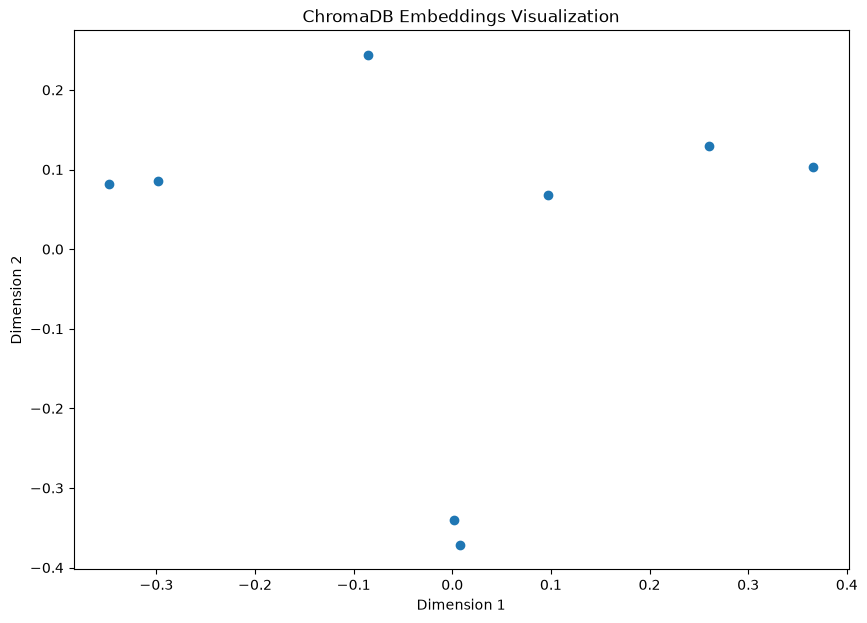

In [ ]:
#vector database collection called hotelmate_knowledge visualize using Principal component analysis 
# statistical method

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

embeddings = np.array(data["embeddings"])

pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("ChromaDB Embeddings Visualization")

plt.show()

In [ ]:
# RAG PIPELINE STEP 4: Query the vector database -- semantic, keyword, hybrid, metadata search
#
# 1. semantic_search  -> pure vector similarity (embeds the query, nearest
#    neighbors in Chroma). Strong on meaning/paraphrase, weak on exact terms.
# 2. keyword_search    -> BM25 (a standard unsupervised lexical ranking model,
#    same family as TF-IDF). Strong on exact terms, blind to meaning.
# 3. hybrid_search      -> Reciprocal Rank Fusion (RRF) of the two rankings.
#    Combines ranked lists without needing to normalize distance scores
#    against BM25 scores onto the same scale.
# 4. metadata_filtered_search -> semantic search restricted to a metadata
#    subset (e.g. only markdown docs, only a specific property) -- scopes
#    the candidate pool before ranking rather than being a ranking method
#    on its own.

In [19]:
import re
from rank_bm25 import BM25Okapi

def tokenize(text: str) -> list[str]:
    return re.findall(r"\w+", text.lower())

# Build the BM25 index once over all stored chunks (reuses `data` from above)
bm25_doc_ids = data["ids"]
bm25_documents = data["documents"]
bm25_corpus = [tokenize(doc) for doc in bm25_documents]
bm25 = BM25Okapi(bm25_corpus)

In [20]:
async def semantic_search(query: str, top_k: int = 3):
    """Pure vector similarity search against the Chroma collection."""

    generated = await embedding_client.get_embeddings([query])
    query_vector = [e.vector for e in generated][0]

    results = collection.query(
        query_embeddings=[query_vector],
        n_results=top_k,
    )

    return list(zip(
        results["ids"][0],
        results["documents"][0],
        results["distances"][0],
    ))

In [21]:
def keyword_search(query: str, top_k: int = 3):
    """Lexical search using BM25 over the stored chunk text."""

    scores = bm25.get_scores(tokenize(query))

    ranked = sorted(
        zip(bm25_doc_ids, bm25_documents, scores),
        key=lambda item: item[2],
        reverse=True,
    )

    return ranked[:top_k]

In [22]:
async def hybrid_search(query: str, top_k: int = 3, k_rrf: int = 60):
    """
    Combine semantic and keyword rankings via Reciprocal Rank Fusion (RRF).

    Each result's fused score is the sum of 1 / (k_rrf + rank) across the
    lists it appears in, so a chunk that ranks well in *both* semantic and
    keyword search rises to the top -- without needing to normalize a cosine
    distance against a BM25 score.
    """

    semantic_results = await semantic_search(query, top_k=len(bm25_doc_ids))
    keyword_results = keyword_search(query, top_k=len(bm25_doc_ids))

    rrf_scores: dict[str, float] = {}

    for rank, (doc_id, _doc, _distance) in enumerate(semantic_results):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1 / (k_rrf + rank + 1)

    for rank, (doc_id, _doc, _score) in enumerate(keyword_results):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1 / (k_rrf + rank + 1)

    id_to_doc = dict(zip(bm25_doc_ids, bm25_documents))
    ranked_ids = sorted(rrf_scores.items(), key=lambda item: item[1], reverse=True)

    return [
        (doc_id, id_to_doc[doc_id], score)
        for doc_id, score in ranked_ids[:top_k]
    ]

In [23]:
async def metadata_filtered_search(query: str, top_k: int = 3, where: dict | None = None):
    """
    Semantic search restricted to chunks matching a metadata filter.
    e.g. where={"file_type": "markdown"} -- scopes the candidate pool
    *before* ranking, useful once you have multiple documents/properties
    stored in the same collection.
    """

    generated = await embedding_client.get_embeddings([query])
    query_vector = [e.vector for e in generated][0]

    results = collection.query(
        query_embeddings=[query_vector],
        n_results=top_k,
        where=where,
    )

    return list(zip(
        results["ids"][0],
        results["documents"][0],
        results["distances"][0],
    ))

In [ ]:
# Each method gets a query suited to its strengths, not one query reused for all four.

semantic_query = "Can I bring my two dogs when I stay?"                                # paraphrased, no literal term overlap
keyword_query = "What's the resort fee?"                                               # exact term likely to appear verbatim
hybrid_query = "What's the deal if I cancel my Advance Purchase booking last minute?"   # mixes a named rate + a vague ask
metadata_query = "What is the cancellation policy?"                                    # generic -- scoped via metadata instead

print("=== Semantic search ===")
print(f"Query: {semantic_query!r}")
for doc_id, doc, distance in await semantic_search(semantic_query):
    print(f"[{doc_id}] distance={distance:.4f}  {doc[:100]}...")

print("\n=== Keyword search (BM25) ===")
print(f"Query: {keyword_query!r}")
for doc_id, doc, score in keyword_search(keyword_query):
    print(f"[{doc_id}] bm25={score:.4f}  {doc[:100]}...")

print("\n=== Hybrid search (RRF) ===")
print(f"Query: {hybrid_query!r}")
for doc_id, doc, score in await hybrid_search(hybrid_query):
    print(f"[{doc_id}] rrf={score:.4f}  {doc[:100]}...")

print("\n=== Metadata-filtered semantic search (file_type=markdown) ===")
print(f"Query: {metadata_query!r}")
for doc_id, doc, distance in await metadata_filtered_search(metadata_query, where={"file_type": "markdown"}):
    print(f"[{doc_id}] distance={distance:.4f}  {doc[:100]}...")

In [ ]:
semantic_query = "Can I bring my two dogs when I stay?"  

print("=== Semantic search ===")
print(f"Query: {semantic_query!r}")
for doc_id, doc, distance in await semantic_search(semantic_query):
    print(f"[{doc_id}] distance={distance:.4f}  {doc[:100]}...")

=== Semantic search ===
Query: 'Can I bring my two dogs when I stay?'
[chunk-7] distance=0.6442  tay, up to 2 pets under 50 lbs each. **Q: How do I get a refund after cancelling?** A: Approved refu...
[chunk-4] distance=0.6995  t** included in the room rate. --- ## 6. Occupancy & Extra Guest Policy - Standard room occupancy: 2...
[chunk-3] distance=0.7426  ype, or occupancy changes are permitted **only** for Flexible, Member, and Corporate rates, subject ...


In [25]:
keyword_query = "What's the resort fee?" 

print("\n=== Keyword search (BM25) ===")
print(f"Query: {keyword_query!r}")
for doc_id, doc, score in keyword_search(keyword_query):
    print(f"[{doc_id}] bm25={score:.4f}  {doc[:100]}...")



=== Keyword search (BM25) ===
Query: "What's the resort fee?"
[chunk-0] bm25=1.8110  # Grand Horizon Hotel & Resort — Booking Policies **Document Type:** Knowledge Base Article **Catego...
[chunk-3] bm25=1.7448  ype, or occupancy changes are permitted **only** for Flexible, Member, and Corporate rates, subject ...
[chunk-7] bm25=1.3153  tay, up to 2 pets under 50 lbs each. **Q: How do I get a refund after cancelling?** A: Approved refu...


In [26]:
hybrid_query = "What's the deal if I cancel my Advance Purchase booking last minute?"   # mixes a named rate + a vague ask

print("\n=== Hybrid search (RRF) ===")
print(f"Query: {hybrid_query!r}")
for doc_id, doc, score in await hybrid_search(hybrid_query):
    print(f"[{doc_id}] rrf={score:.4f}  {doc[:100]}...")



=== Hybrid search (RRF) ===
Query: "What's the deal if I cancel my Advance Purchase booking last minute?"
[chunk-2] rrf=0.0320  ws - **Flexible Rate:** Free cancellation up to 24 hours before the check-in date (local hotel time)...
[chunk-6] rrf=0.0320  by property at no additional cost. 2. Cover reasonable transportation to the alternate property. 3. ...
[chunk-0] rrf=0.0315  # Grand Horizon Hotel & Resort — Booking Policies **Document Type:** Knowledge Base Article **Catego...


In [27]:
metadata_query = "What is the cancellation policy?"   

print("\n=== Metadata-filtered semantic search (file_type=markdown) ===")
print(f"Query: {metadata_query!r}")
for doc_id, doc, distance in await metadata_filtered_search(metadata_query, where={"file_type": "markdown"}):
    print(f"[{doc_id}] distance={distance:.4f}  {doc[:100]}...")


=== Metadata-filtered semantic search (file_type=markdown) ===
Query: 'What is the cancellation policy?'
[chunk-2] distance=0.7288  ws - **Flexible Rate:** Free cancellation up to 24 hours before the check-in date (local hotel time)...
[chunk-1] distance=0.7568  to 24 hrs before arrival | | Advance Purchase | Charged in full at booking | Non-refundable, non-cha...
[chunk-6] distance=0.7766  by property at no additional cost. 2. Cover reasonable transportation to the alternate property. 3. ...


In [28]:
# RAG PIPELINE STEP 5: Agentic RAG -- give the agent a retrieval tool
#
# This is what makes it *agentic* RAG rather than plain RAG: instead of us
# always fetching chunks and stuffing them into the prompt, we hand the LLM
# a callable tool. The agent itself decides -- per user message -- whether
# the question needs a policy lookup at all, and if so, what to search for.

from typing import Annotated

from agent_framework import Agent

In [29]:
async def search_hotel_policies(
    query: Annotated[str, "The guest's question, used to search the hotel policy knowledge base."],
) -> str:
    """
    Search the Grand Horizon Hotel & Resort booking-policy knowledge base
    and return the most relevant policy excerpts for the given question.
    Call this whenever the guest asks about reservations, cancellations,
    check-in/out times, payments, occupancy, pets, loyalty tiers, or any
    other hotel booking policy. Do not guess at policy details without
    calling this first.
    """

    results = await hybrid_search(query, top_k=3)

    if not results:
        return "No relevant policy information was found."

    return "\n\n".join(
        f"[{doc_id}] {doc}" for doc_id, doc, _score in results
    )

In [31]:
agent = Agent(
    client=client,  # the GeminiChatClient from earlier -- no longer shadowed
    name="HotelPolicyAgent",
    instructions=(
        "You are the Grand Horizon Hotel & Resort booking assistant. "
        "Use the search_hotel_policies tool to look up the hotel's actual "
        "policies before answering any question about reservations, "
        "cancellations, check-in/out, payments, occupancy, pets, or loyalty "
        "programs. Answer only from what the tool returns -- if the tool "
        "doesn't cover something, say you don't have that information "
        "rather than guessing. Keep answers brief and guest-friendly."
    ),
    tools=[search_hotel_policies],
)

In [32]:
async def run_agent(prompt):
    print("You: " + prompt)
    response = await agent.run(prompt)
    print(response)

In [ ]:
await run_agent("What's the cancellation policy for an Advance Purchase booking?")

In [35]:
await run_agent("Can I bring my two dogs when I stay?")

You: Can I bring my two dogs when I stay?
Yes, you may bring your two dogs under the following conditions:

* **Location:** Pets are only permitted at our designated "Pet-Friendly" properties.
* **Pet Limit & Weight:** A maximum of 2 pets per room is allowed, with a weight limit of 50 lbs per pet.
* **Fee:** A non-refundable pet fee of $75 per stay applies. 

Please make sure to confirm that your selected property is designated as pet-friendly when booking!
